In [1]:
# 한글 글꼴 설치
!apt-get -qq install fonts-noto-cjk
!rm -rf /root/.cache/matplotlib/* # 캐시 재설정

In [2]:
# 런타임 다시 시작 후 실행
%matplotlib inline
import matplotlib as mpl
# Noto Sans CJK 폰트를 기본으로 설정
mpl.rc('font', family='Noto Sans CJK JP')
mpl.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

In [3]:
# DeprecationWarning 메시지 방지
import sys
import IPython

# 화면 출력 스트림을 가로채서 경고문만 지우는 필터 클래스
class WarningFilter:
    def __init__(self, stream):
        self.stream = stream
    def write(self, data):
        # 경고 메시지 키워드가 포함되어 있다면 출력을 무시함
        if "DeprecationWarning" in data or "jupyter_client/session.py" in data:
            return
        if "DataFrames with non-bool types" in data: # mlxtend 경고도 함께 차단
            return
        self.stream.write(data)
    def flush(self):
        self.stream.flush()

# 시스템 출력 통로에 필터 적용
sys.stderr = WarningFilter(sys.stderr)


In [4]:
# T04_01.py
import numpy as np
from sklearn.cluster import KMeans

# 데이터 생성
data = np.array([
  [2, 5], [3, 7], [15, 30], [16, 28], [14, 32]
]) # ①

# K-Means 모델 생성 및 학습
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10) # ②
labels = kmeans.fit_predict(data) # ③

# 군집 결과 및 중심점 확인
centers = kmeans.cluster_centers_ # ④
for i in range(len(centers)): # ⑤
  print(f"군집 {i} 중심: {centers[i]}")
print()

for i in range(len(labels)):
  print(f"{data[i]} -> 군집 {labels[i]}") # ⑥

군집 0 중심: [2.5 6. ]
군집 1 중심: [15. 30.]

[2 5] -> 군집 0
[3 7] -> 군집 0
[15 30] -> 군집 1
[16 28] -> 군집 1
[14 32] -> 군집 1


In [5]:
# T04_05.py
import numpy as np
from sklearn.cluster import DBSCAN

# 데이터 생성(두 개의 밀집 군집 + 몇 개의 이상치)
data = np.array([
  [1, 1], [1.2, 0.8], [0.8, 1.1], [1.1, 1.2], [0.9, 0.9], # 군집 1
  [5, 5], [5.1, 4.9], [4.9, 5.2], [5.2, 5.1], [4.8, 4.9], # 군집 2
  [8, 1], [0, 6] # 노이즈(이상치)
]) # ①

# DBSCAN 모델 생성
dbscan = DBSCAN(eps=0.4, min_samples=3) # ②

# 군집 수행
labels = dbscan.fit_predict(data) # ③

# 결과 출력
for i in range(len(labels)):
  print(f"{data[i]} -> 군집 {labels[i]}") # ④

[1. 1.] -> 군집 0
[1.2 0.8] -> 군집 0
[0.8 1.1] -> 군집 0
[1.1 1.2] -> 군집 0
[0.9 0.9] -> 군집 0
[5. 5.] -> 군집 1
[5.1 4.9] -> 군집 1
[4.9 5.2] -> 군집 1
[5.2 5.1] -> 군집 1
[4.8 4.9] -> 군집 1
[8. 1.] -> 군집 -1
[0. 6.] -> 군집 -1


In [6]:
# T04_06.py
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 데이터 불러오기
X = load_iris().data # ①

# 표준화
X_scaled = StandardScaler().fit_transform(X) # ②

# PCA로 2차원 축소
pca = PCA(n_components=2) # ③
X_pca = pca.fit_transform(X_scaled) # ④

# 결과 확인
print("원본 차원:", X.shape) # ⑤
print("축소 후 차원:", X_pca.shape) # ⑤
print("PC1:", round(pca.explained_variance_ratio_[0], 3)) # ⑥
print("PC2:", round(pca.explained_variance_ratio_[1], 3)) # ⑥
print("총합:", round(pca.explained_variance_ratio_.sum(), 3))
print()

for i in range(5): # ⑦
  print(X[i], X_pca[i])

원본 차원: (150, 4)
축소 후 차원: (150, 2)
PC1: 0.73
PC2: 0.229
총합: 0.958

[5.1 3.5 1.4 0.2] [-2.26470281  0.4800266 ]
[4.9 3.  1.4 0.2] [-2.08096115 -0.67413356]
[4.7 3.2 1.3 0.2] [-2.36422905 -0.34190802]
[4.6 3.1 1.5 0.2] [-2.29938422 -0.59739451]
[5.  3.6 1.4 0.2] [-2.38984217  0.64683538]


In [7]:
# T04_07.py
from mlxtend.frequent_patterns import apriori, association_rules
import pandas as pd

# 거래별 구매 상품(원-핫 인코딩 형태)
data = {
  '빵': [1, 0, 1, 1, 0],
  '우유': [1, 1, 1, 0, 1],
  '계란': [0, 1, 1, 1, 0],
  '치즈': [0, 0, 0, 1, 0]
}
df = pd.DataFrame(data) # ①

# 빈발 항목집합 찾기
frequent_itemsets = apriori(df, min_support=0.4, use_colnames=True) # ②
print(frequent_itemsets)
print()

# 연관 규칙 생성
rules = association_rules(frequent_itemsets,
metric="confidence",
min_threshold=0.6) # ③

print(rules[[
  'antecedents',
  'consequents',
  'support',
  'confidence',
  'lift'
]].sort_values('lift', ascending=False)) # ④

   support  itemsets
0      0.6       (빵)
1      0.8      (우유)
2      0.6      (계란)
3      0.4   (빵, 우유)
4      0.4   (빵, 계란)
5      0.4  (계란, 우유)

  antecedents consequents  support  confidence      lift
1         (빵)        (계란)      0.4    0.666667  1.111111
2        (계란)         (빵)      0.4    0.666667  1.111111
0         (빵)        (우유)      0.4    0.666667  0.833333
3        (계란)        (우유)      0.4    0.666667  0.833333


In [8]:
# Q04_01.py
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor
import matplotlib.pyplot as plt

np.random.seed(42)

segment_1 = pd.DataFrame({ # ①
  '구매금액': np.random.normal(500000, 100000, 50),
  '구매빈도': np.random.normal(20, 5, 50),
  '최근구매일': np.random.normal(10, 3, 50),
  '평균구매액': np.random.normal(25000, 5000, 50),
  '리뷰개수': np.random.normal(15, 3, 50)
})

segment_2 = pd.DataFrame({
  '구매금액': np.random.normal(200000, 50000, 50),
  '구매빈도': np.random.normal(8, 2, 50),
  '최근구매일': np.random.normal(30, 10, 50),
  '평균구매액': np.random.normal(25000, 5000, 50),
  '리뷰개수': np.random.normal(5, 2, 50)
})

segment_3 = pd.DataFrame({
  '구매금액': np.random.normal(1000000, 200000, 50),
  '구매빈도': np.random.normal(40, 10, 50),
  '최근구매일': np.random.normal(3, 1, 50),
  '평균구매액': np.random.normal(25000, 5000, 50),
  '리뷰개수': np.random.normal(30, 5, 50)
})

outliers = pd.DataFrame({ # ②
  '구매금액': [5000000, 100000],
  '구매빈도': [100, 1],
  '최근구매일': [1, 200],
  '평균구매액': [50000, 100000],
  '리뷰개수': [50, 0]
})

df = pd.concat([segment_1, segment_2, segment_3, outliers], ignore_index=True) # ③

df['고객ID'] = [f'C{str(i).zfill(4)}' for i in range(len(df))] # ④

print("=== 고객 데이터 기본 통계 ===")
print(df.describe()) # ⑤
print(f"전체 고객 수: {len(df)}") # ⑥

=== 고객 데이터 기본 통계 ===
               구매금액        구매빈도       최근구매일          평균구매액        리뷰개수
count  1.520000e+02  152.000000  152.000000     152.000000  152.000000
mean   5.679842e+05   23.175410   16.035931   25742.164612   16.629955
std    4.915355e+05   15.906960   20.284597    8074.604076   10.973598
min    3.793663e+04    1.000000    0.303113   11745.150958    0.000000
25%    2.373254e+05    9.213134    3.749183   21385.574012    6.134290
50%    4.765855e+05   19.730410    9.908162   25262.973281   15.604369
75%    8.293905e+05   35.586405   24.358835   28555.618478   26.398031
max    5.000000e+06  100.000000  200.000000  100000.000000   50.000000
전체 고객 수: 152


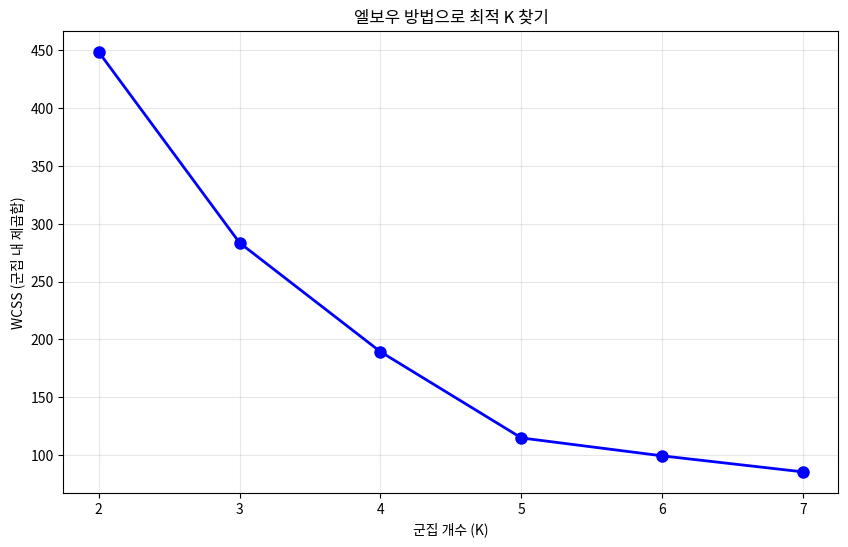

=== 세그먼트별 특성 ===
              구매금액       구매빈도       최근구매일          평균구매액       리뷰개수
세그먼트                                                               
0     1.018619e+06  41.132245    3.122728   25621.223918  29.576779
1     3.360145e+05  13.967532   20.960400   25055.609872   9.997583
2     1.000000e+05   1.000000  200.000000  100000.000000   0.000000


In [9]:
# Q04_02.py
features = ['구매금액', '구매빈도', '최근구매일', '평균구매액', '리뷰개수'] # ①

X = df[features]
X_scaled = StandardScaler().fit_transform(X) # ②
inertias = []

K_range = range(2, 8)
for k in K_range: # ③
  kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
  kmeans.fit(X_scaled)
  inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('군집 개수 (K)')
plt.ylabel('WCSS (군집 내 제곱합)')
plt.title('엘보우 방법으로 최적 K 찾기')
plt.grid(True, alpha=0.3)
plt.show() # ④

optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['세그먼트'] = kmeans.fit_predict(X_scaled) # ⑤

print("=== 세그먼트별 특성 ===")
segment_summary = df.groupby('세그먼트')[features].mean()
segment_names = {
  0: 'VIP 고객',
  1: '일반 고객',
  2: '신규 고객'
}

print(segment_summary) # ⑥

=== PCA 설명 분산 ===
PC1: 61.1%
PC2: 27.1%
총: 88.2%


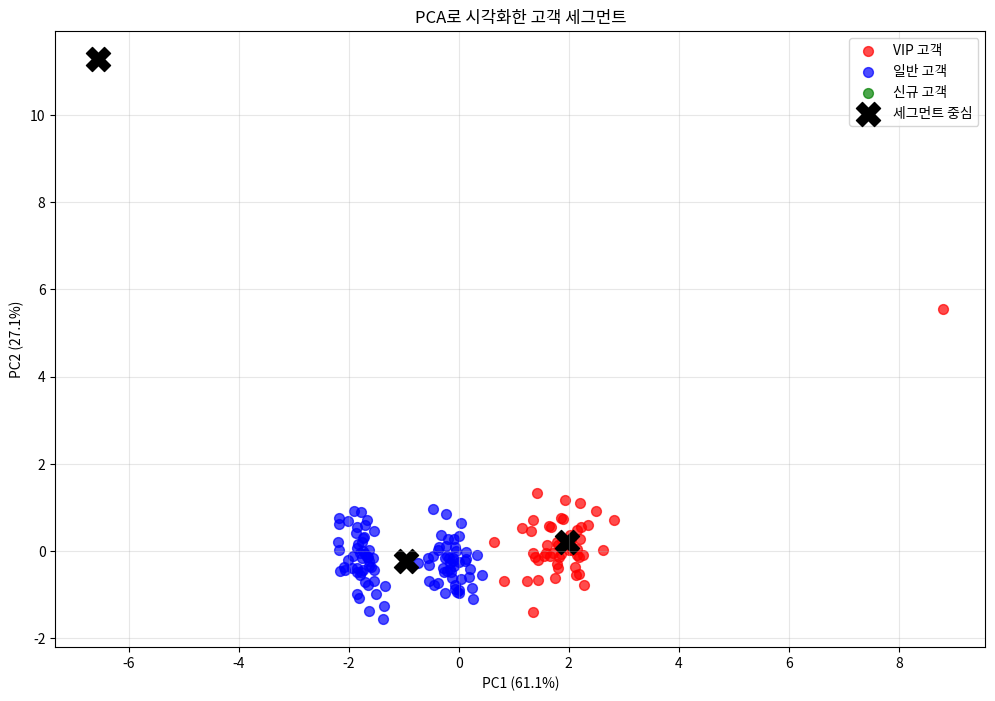

In [10]:
# Q04_03.py
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled) # ①

print(f"=== PCA 설명 분산 ===")
print(f"PC1: {pca.explained_variance_ratio_[0]:.1%}")
print(f"PC2: {pca.explained_variance_ratio_[1]:.1%}")
print(f"총: {pca.explained_variance_ratio_.sum():.1%}") # ②

plt.figure(figsize=(12, 8))
colors = ['red', 'blue', 'green']

for seg_id, seg_name in segment_names.items(): # ③
  mask = df['세그먼트'] == seg_id
  plt.scatter(X_pca[mask, 0], X_pca[mask, 1],\
              c=colors[seg_id], label=seg_name, s=50, alpha=0.7)

centers_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1],
            c='black', marker='X', s=300, label='세그먼트 중심') # ④
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('PCA로 시각화한 고객 세그먼트')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show() # ⑤

=== 이상 고객 탐지 결과 ===
이상 고객: 8명
이상 고객 상세:
      고객ID          구매금액        구매빈도       최근구매일      LOF점수
6    C0006  6.579213e+05   15.803912   15.658558   1.419077
29   C0029  4.708306e+05   10.062155    8.489573   1.810786
78   C0078  2.034901e+05    9.248240   51.898029   1.361609
92   C0092  1.705318e+05    8.489933   16.797668   1.359209
118  C0118  1.019866e+06   21.292081    3.481009   1.695860
121  C0121  1.108672e+06   56.764373    3.471468   1.369051
150  C0150  5.000000e+06  100.000000    1.000000   8.074977
151  C0151  1.000000e+05    1.000000  200.000000  12.844252


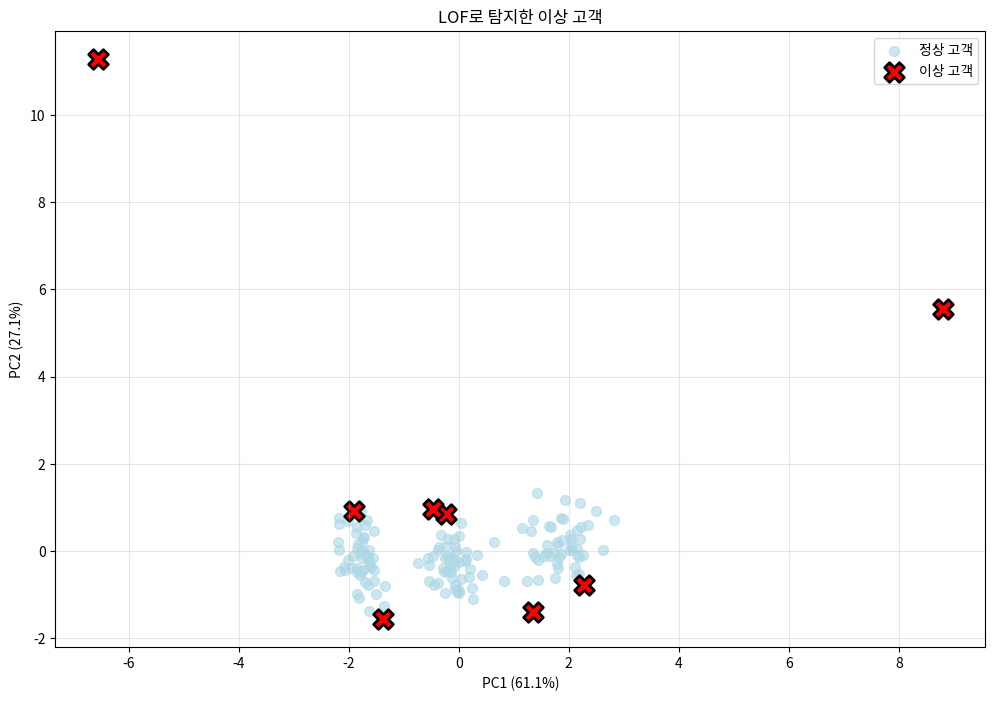

In [11]:
# Q04_04.py
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05) # ①

df['이상여부'] = lof.fit_predict(X_scaled)
df['LOF점수'] = -lof.negative_outlier_factor_ # ②
anomalies = df[df['이상여부'] == -1]

print(f"=== 이상 고객 탐지 결과 ===") # ③
print(f"이상 고객: {len(anomalies)}명")
print("이상 고객 상세:")
print(anomalies[['고객ID', '구매금액', '구매빈도', '최근구매일', 'LOF점수']])

plt.figure(figsize=(12, 8))
normal_mask = df['이상여부'] == 1
plt.scatter(X_pca[normal_mask, 0], X_pca[normal_mask, 1],
            c='lightblue', s=50, alpha=0.6, label='정상 고객') # ④
plt.scatter(X_pca[~normal_mask, 0], X_pca[~normal_mask, 1],
            c='red', s=200, marker='X', label='이상 고객',
            edgecolors='black', linewidths=2) # ⑤
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('LOF로 탐지한 이상 고객')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show() # ⑥

In [12]:
# Q04_05.py
print("=== 비즈니스 인사이트 및 실행 전략 ===")
for seg_id, seg_name in segment_names.items(): # ①
  seg_data = df[df['세그먼트'] == seg_id]
  avg_purchase = seg_data['구매금액'].mean()
  avg_frequency = seg_data['구매빈도'].mean()
  avg_recency = seg_data['최근구매일'].mean()
  print(f"[{seg_name}] (고객 수: {len(seg_data)}명)")
  print(f"평균 구매금액: {avg_purchase:,.0f}원")
  print(f"평균 구매빈도: {avg_frequency:.1f}회/년")
  print(f"평균 최근구매: {avg_recency:.1f}일 전")
  if seg_id == 0: # VIP
    print(f"전략: 프리미엄 혜택 제공, VIP 전용 이벤트")
  elif seg_id == 1: # 일반
    print(f"전략: 구매 빈도 증가 유도, 쿠폰 제공")
  else: # 신규
    print(f"전략: 재구매 유도, 환영 할인")
  print(f"\n")

print(f"[이상 고객]")
print(f"{len(anomalies)}명 탐지되어 추가 검토 필요") # ②
print(f"사기 가능성 또는 테스트 계정 확인 권장")

=== 비즈니스 인사이트 및 실행 전략 ===
[VIP 고객] (고객 수: 52명)
평균 구매금액: 1,018,619원
평균 구매빈도: 41.1회/년
평균 최근구매: 3.1일 전
전략: 프리미엄 혜택 제공, VIP 전용 이벤트


[일반 고객] (고객 수: 99명)
평균 구매금액: 336,014원
평균 구매빈도: 14.0회/년
평균 최근구매: 21.0일 전
전략: 구매 빈도 증가 유도, 쿠폰 제공


[신규 고객] (고객 수: 1명)
평균 구매금액: 100,000원
평균 구매빈도: 1.0회/년
평균 최근구매: 200.0일 전
전략: 재구매 유도, 환영 할인


[이상 고객]
8명 탐지되어 추가 검토 필요
사기 가능성 또는 테스트 계정 확인 권장
